### Checking if log odds ratio distributions are better modeled as Gaussian or double Gaussian.

In [166]:
import os
import sys
import numpy as np
import pandas as pd
from scipy.stats import norm
from scipy.optimize import minimize
from tqdm.auto import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from odds_ratio_test import occupancy_filter

# Ensure the src directory is in the Python path
scripts = os.path.abspath('')
src_path = os.path.abspath(os.path.join(scripts, '..', 'src'))
if src_path not in sys.path:
    sys.path.append(src_path)

# Define paths to data and results directories
odds_ratio_results = os.path.join(scripts, "..", "results/odds_ratio_test/")

Define functions

In [167]:
def gauss_fun(x,mu,sigma):
    """Gaussian function."""
    
    amp = np.power(2*np.pi*np.power(sigma,2),0.5)
    return np.exp(-np.power(x - mu, 2.) / (2 * np.power(sigma, 2.))) / amp

In [168]:
def gausslogl(x, mu, sigma):
    """Calculate the log-likelihood of a Gaussian distribution."""
    
    p = gauss_fun(x,mu,sigma)
    
    logL = np.nansum(np.log(p), axis = 0)
    
    return logL

In [169]:
def dgauss_fun(params,x):
    """Double Gaussian function."""
    
    mu1 = params[0]
    mu2 = params[1]
    sigma1 = params[2]
    sigma2 = params[3]
    w = params[4]
    
    gauss1 = gauss_fun(x,mu1,sigma1)
    gauss2 = gauss_fun(x,mu2,sigma2)
    
    p = w*gauss1 + (1-w)*gauss2
    
    return p

def dgausslogl(params,x):
    """Calculate the log-likelihood of a double Gaussian distribution."""

    p = dgauss_fun(params,x)
    
    logL = np.nansum(np.log(p))
    
    return -logL

In [170]:
def param_optimization(data):
    """Optimize parameters for Gaussian models.

    Args:
        data (array-like): Input data for model fitting.

    Returns:
        tuple: Optimized parameters for single and double Gaussian models, and their log-likelihoods.
    """

    mu = np.nanmean(data)
    sigma = np.nanstd(data)
    params_single = [mu, sigma]

    logL1 = gausslogl(data, mu, sigma)
    logL2 = np.zeros(np.shape(logL1))

    params_double = np.zeros(5)

    params0 = [mu - sigma, mu + sigma, sigma, sigma, 0.4]
    result = minimize(dgausslogl, params0, args=data, method='Nelder-Mead')
    params_double = result.x
    logL2 = -dgausslogl(params_double, data)

    return params_single, params_double, logL1, logL2


In [171]:
def bic_calc(n,k,logL1,logL2):
    """Calculate the Bayesian Information Criterion (BIC) for model comparison.

    Args:
        n (int): Number of data points.
        k (list): List containing the number of parameters for each model.
        logL1 (float): Log-likelihood of the first model.
        logL2 (float): Log-likelihood of the second model.

    Returns:
        float: The difference in BIC between the two models.
    """

    BIC = np.zeros(2)
    BIC[0] = np.log(n)*k[0] - 2*logL1
    BIC[1] = np.log(n)*k[1] - 2*logL2

    # Here I take the difference between the two BIC calculations, i.e. BIC(2-Gauss) - BIC(1-Gauss)
    # If BIC > 0, Single Gaussian Better, if BIC < 0, Double Gaussian Better   
    BIC = BIC[1] - BIC[0]

    if BIC > 0: print('Single')
    else: print('Double')

    return BIC

In [172]:
def plot_it(data, params_double):
    fig, ax = plt.subplots(figsize=(8, 6))

    # Histogram of the true log odds ratios, filtered for occupancy
    sns.histplot(
        data,
        kde=False,
        bins=200,
        stat="density",
        ax=ax,
        legend=False
    )

    x = np.linspace(
        data.min(),
        data.max(),
        100,
    )

    # Gaussian fit to the true log odds ratios
    ax.plot(
        x,
        norm.pdf(
            x,
            np.mean(data),
            np.std(data),
        ),
        linestyle="--",
        label="Gaussian fit to true\ndistribution",
    )

    # Normal distribution using the average bootstrapped stats
    ax.plot(
        x,
        dgauss_fun(
            params_double, x
        ),
        linestyle="--",
        label="Double Gaussian fit to true\ndistribution",
    )


    ax.axvline(
                x=params_double[0],
                linestyle="dotted"
            )

    ax.axvline(
                x=params_double[1],
                linestyle="dotted"
            )

Import data

In [173]:
loss_results_all = pd.read_csv(
    str(odds_ratio_results) + "loss_odds_results_all.csv"
)
dup_results_all = pd.read_csv(
    str(odds_ratio_results) + "duplication_odds_results_all.csv"
)
total_occ_arr = loss_results_all["Occupancy"].values
loss_log_odds_ratios = loss_results_all["Log odds ratio"].values
dup_log_odds_ratios = dup_results_all["Log odds ratio"].values

Filter for occupancy thresholds

In [174]:
dup_50_98_lors = occupancy_filter(
    dup_log_odds_ratios, 50, 98, total_occ_arr
)
loss_50_95_lors = occupancy_filter(
    loss_log_odds_ratios, 50, 95, total_occ_arr
)

Check whether loss distribution is bimodal

In [175]:
data = loss_50_95_lors
params_single, params_double, logL1, logL2 = param_optimization(data)
bic = bic_calc(len(data), [2,5], logL1, logL2)

Double


In [176]:
len(data)

5269

In [177]:
params_single

[np.float64(-0.6629752260879566), np.float64(1.5413813505684821)]

In [178]:
params_double

array([-0.76957994,  2.60684924,  1.43714006,  0.92711937,  0.96842795])

In [179]:
bic

np.float64(-18.090022489472176)

In [180]:
logL1

np.float64(-9756.17275751833)

In [181]:
logL2

np.float64(-9734.27335246828)

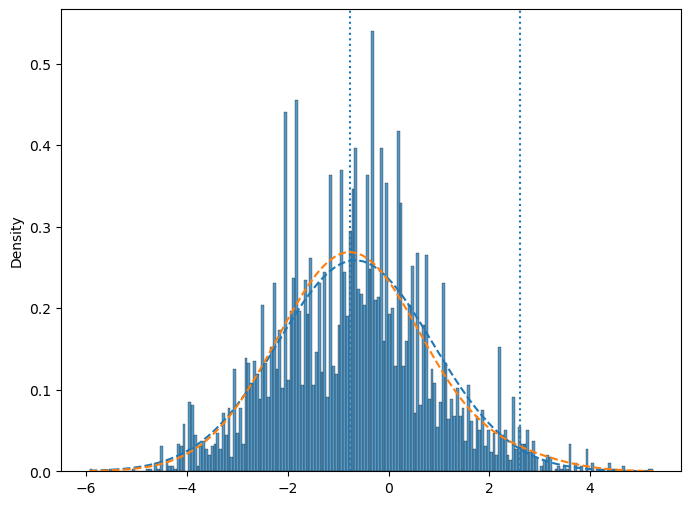

In [182]:
plot_it(data, params_double)

Check whether duplication distribution is bimodal

In [183]:
data = dup_50_98_lors

params_single, params_double, logL1, logL2 = param_optimization(data)
bic = bic_calc(len(data), [2,5], logL1, logL2)

Double


In [184]:
len(data)

7875

In [185]:
params_single

[np.float64(0.025141820982255005), np.float64(0.9948985446732754)]

In [186]:
params_double

array([-0.01609611,  0.06298374,  0.65112695,  1.22724056,  0.47857372])

In [187]:
bic

np.float64(-188.4877901668042)

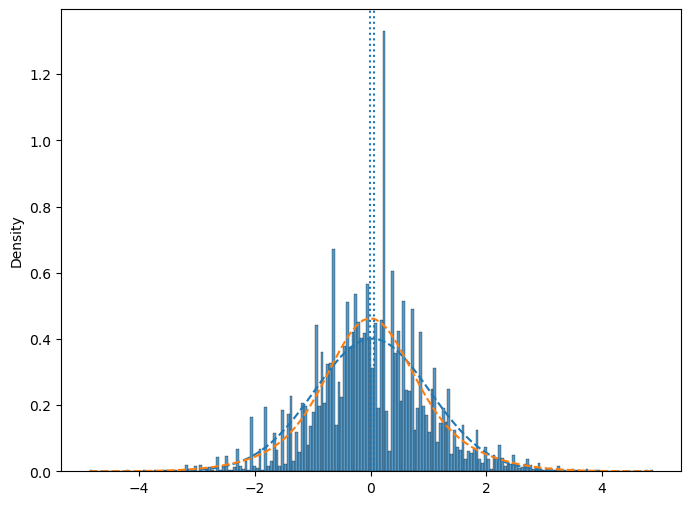

In [188]:
plot_it(data, params_double)